# Dataset Exploration and Visualization

This notebook analyzes the preprocessed YOLO vehicle detection dataset to ensure data quality before training.

**What this notebook does:**
1. Counts training, validation, and test images
2. Displays random images with bounding boxes overlaid
3. Plots class distribution and objects per image
4. Analyzes bounding box sizes and image dimensions
5. Provides dataset statistics summary

**Requirements:** `pip install opencv-python matplotlib numpy`

In [1]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================
# CONFIGURATION
# ============================================
DATASET_DIR = "vehicle_dataset"
IMAGES_DIR = os.path.join(DATASET_DIR, "images")
LABELS_DIR = os.path.join(DATASET_DIR, "labels")
SPLITS = ["train", "val", "test"]

# Check if directories exist
if not os.path.exists(DATASET_DIR):
    print(f"⚠️ WARNING: Dataset directory '{DATASET_DIR}' not found!")
    print("Make sure you're running this from the correct directory.")
else:
    print(f"✓ Dataset directory found: {DATASET_DIR}")

✓ Dataset directory found: vehicle_dataset


## 1. Count Images per Split

In [2]:
def count_dataset_images():
    """Count images in each split and display summary."""
    print("\n" + "="*60)
    print("DATASET IMAGE COUNTS")
    print("="*60)
    
    total_images = 0
    total_labels = 0
    
    for split in SPLITS:
        img_pattern = os.path.join(IMAGES_DIR, split, "*.jpg")
        lbl_pattern = os.path.join(LABELS_DIR, split, "*.txt")
        
        img_count = len(glob.glob(img_pattern))
        lbl_count = len(glob.glob(lbl_pattern))
        
        total_images += img_count
        total_labels += lbl_count
        
        print(f"{split.upper():8s}: {img_count:4d} images, {lbl_count:4d} labels")
    
    print("="*60)
    print(f"{'TOTAL':8s}: {total_images:4d} images, {total_labels:4d} labels")
    print("="*60 + "\n")
    
    return total_images, total_labels

# Run the count
count_dataset_images()


DATASET IMAGE COUNTS
TRAIN   : 1050 images, 1050 labels
VAL     :  300 images,  300 labels
TEST    :  150 images,  150 labels
TOTAL   : 1500 images, 1500 labels



(1500, 1500)

## 2. Dataset Statistics (Class Distribution, Objects per Image, Box Sizes)

Parsing training labels... (This may take a moment)
  Processing: 210/1050...
  Processing: 420/1050...
  Processing: 630/1050...
  Processing: 840/1050...
  Processing: 1050/1050...
✓ Parsed 1050 label files



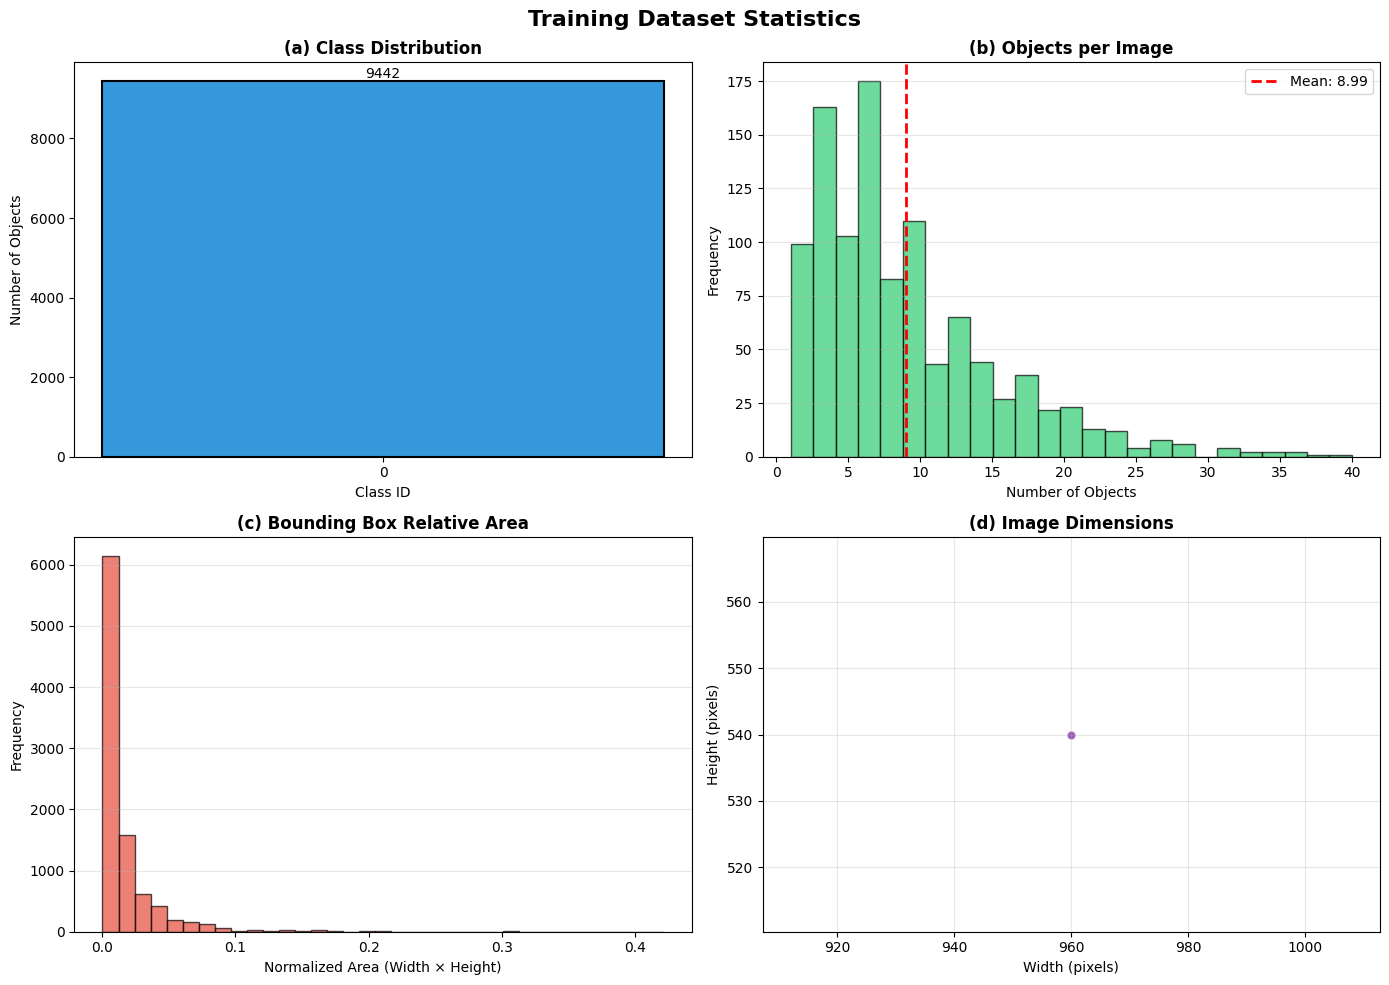

✓ Statistics plots generated!


In [3]:
def plot_dataset_statistics():
    """Parse training labels and plot 4 statistics plots."""
    print("Parsing training labels... (This may take a moment)")
    
    train_labels = glob.glob(os.path.join(LABELS_DIR, "train", "*.txt"))
    
    if not train_labels:
        print("ERROR: No training labels found!")
        return
    
    class_counts = {}
    objects_per_image = []
    box_areas = []
    image_widths = []
    image_heights = []

    # Parse all label files
    for idx, label_path in enumerate(train_labels):
        if (idx + 1) % max(1, len(train_labels) // 5) == 0:
            print(f"  Processing: {idx + 1}/{len(train_labels)}...")
            
        img_path = label_path.replace("labels", "images").replace(".txt", ".jpg")
        
        # Read image dimensions
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                h, w = img.shape[:2]
                image_widths.append(w)
                image_heights.append(h)
        
        # Parse bounding boxes from YOLO format
        with open(label_path, "r") as f:
            lines = f.readlines()
            objects_per_image.append(len(lines))
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    box_w = float(parts[3])
                    box_h = float(parts[4])
                    
                    class_counts[class_id] = class_counts.get(class_id, 0) + 1
                    box_areas.append(box_w * box_h)  # Relative area (0.0 to 1.0)
    
    print(f"✓ Parsed {len(train_labels)} label files\n")
    
    # Create 4 plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Training Dataset Statistics', fontsize=16, fontweight='bold')
    
    # Plot 1: Class Distribution
    ax = axes[0, 0]
    if class_counts:
        classes = sorted(class_counts.keys())
        counts = [class_counts[c] for c in classes]
        bars = ax.bar(classes, counts, color='#3498db', edgecolor='black', linewidth=1.5)
        ax.set_title('(a) Class Distribution', fontsize=12, fontweight='bold')
        ax.set_xlabel('Class ID')
        ax.set_ylabel('Number of Objects')
        ax.set_xticks(classes)
        
        # Add count labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontsize=10)
    
    # Plot 2: Objects per Image
    ax = axes[0, 1]
    ax.hist(objects_per_image, bins=25, color='#2ecc71', edgecolor='black', alpha=0.7)
    ax.set_title('(b) Objects per Image', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Objects')
    ax.set_ylabel('Frequency')
    mean_objects = np.mean(objects_per_image)
    ax.axvline(mean_objects, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_objects:.2f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: Bounding Box Sizes (Relative Area)
    ax = axes[1, 0]
    ax.hist(box_areas, bins=35, color='#e74c3c', edgecolor='black', alpha=0.7)
    ax.set_title('(c) Bounding Box Relative Area', fontsize=12, fontweight='bold')
    ax.set_xlabel('Normalized Area (Width × Height)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 4: Image Dimensions Scatter
    ax = axes[1, 1]
    if image_widths and image_heights:
        ax.scatter(image_widths, image_heights, color='#9b59b6', alpha=0.5, 
                  edgecolor='white', s=40)
        ax.set_title('(d) Image Dimensions', fontsize=12, fontweight='bold')
        ax.set_xlabel('Width (pixels)')
        ax.set_ylabel('Height (pixels)')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Statistics plots generated!")

# Run the analysis
plot_dataset_statistics()

## 3. Visualize Random Samples with Bounding Boxes


Visualizing 4 random train samples with bounding boxes...



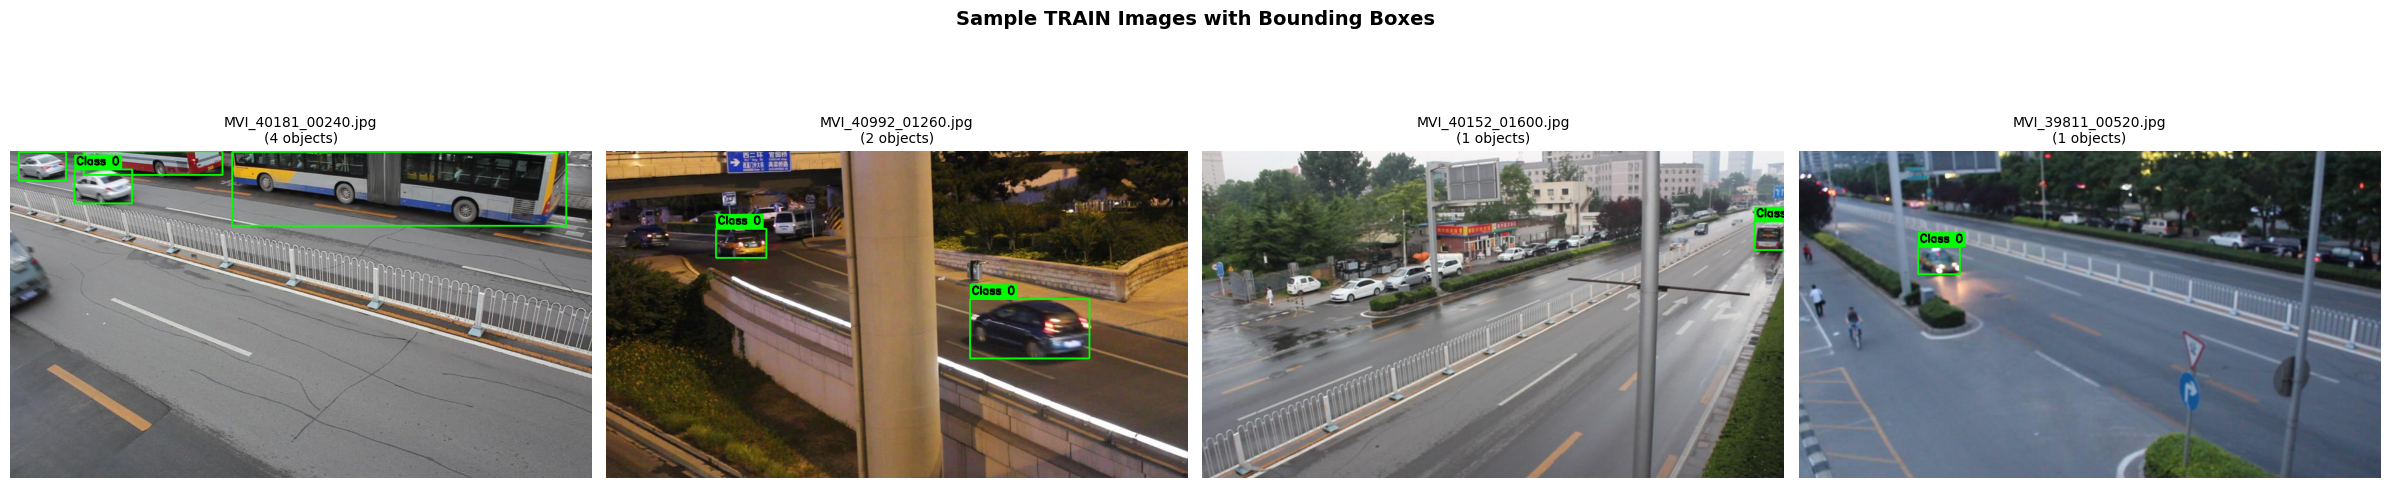

✓ Displayed 4 sample images!


In [4]:
def visualize_random_samples(num_samples=4, split="train"):
    """Randomly select images and display with bounding boxes."""
    print(f"\nVisualizing {num_samples} random {split} samples with bounding boxes...\n")
    
    train_img_dir = os.path.join(IMAGES_DIR, split)
    imgs = glob.glob(os.path.join(train_img_dir, "*.jpg"))
    
    if not imgs:
        print(f"ERROR: No {split} images found!")
        return

    samples = random.sample(imgs, min(num_samples, len(imgs)))
    
    # Create subplots
    fig, axes = plt.subplots(1, len(samples), figsize=(6*len(samples), 6))
    if len(samples) == 1:
        axes = [axes]
    
    fig.suptitle(f'Sample {split.upper()} Images with Bounding Boxes', 
                 fontsize=14, fontweight='bold')
    
    for ax, img_path in zip(axes, samples):
        # Read and convert image
        img = cv2.imread(img_path)
        if img is None:
            print(f"WARNING: Could not read {img_path}")
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img_rgb.shape
        
        # Make a copy for drawing
        img_display = img_rgb.copy()
        
        # Read corresponding labels (YOLO format)
        label_path = img_path.replace("images", "labels").replace(".jpg", ".txt")
        
        num_boxes = 0
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_center, y_center, box_w, box_h = map(float, parts[1:])
                        
                        # Convert from normalized YOLO format to pixel coordinates
                        x1 = int((x_center - box_w / 2) * w)
                        y1 = int((y_center - box_h / 2) * h)
                        x2 = int((x_center + box_w / 2) * w)
                        y2 = int((y_center + box_h / 2) * h)
                        
                        # Clip to image boundaries
                        x1, y1 = max(0, x1), max(0, y1)
                        x2, y2 = min(w, x2), min(h, y2)
                        
                        # Draw bounding box (green rectangle)
                        cv2.rectangle(img_display, (x1, y1), (x2, y2), (0, 255, 0), 2)
                        
                        # Draw label background
                        label_text = f"Class {class_id}"
                        text_size = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 
                                                   0.6, 2)[0]
                        cv2.rectangle(img_display, (x1, y1 - text_size[1] - 10),
                                    (x1 + text_size[0] + 5, y1), (0, 255, 0), -1)
                        
                        # Draw label text
                        cv2.putText(img_display, label_text, (x1 + 3, y1 - 8), 
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
                        
                        num_boxes += 1
        
        # Display image
        ax.imshow(img_display)
        ax.set_title(f'{os.path.basename(img_path)}\n({num_boxes} objects)', 
                    fontsize=10)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Displayed {len(samples)} sample images!")

# Visualize random training samples
visualize_random_samples(num_samples=4, split="train")

## 4. Dataset Summary Report

In [5]:
def print_dataset_summary():
    """Print a comprehensive summary of the dataset."""
    print("\n" + "="*70)
    print("DATASET SUMMARY REPORT")
    print("="*70)
    
    # Count images and labels
    total_images = 0
    total_labels = 0
    split_info = {}
    
    for split in SPLITS:
        img_pattern = os.path.join(IMAGES_DIR, split, "*.jpg")
        lbl_pattern = os.path.join(LABELS_DIR, split, "*.txt")
        
        img_count = len(glob.glob(img_pattern))
        lbl_count = len(glob.glob(lbl_pattern))
        
        total_images += img_count
        total_labels += lbl_count
        split_info[split] = (img_count, lbl_count)
    
    # Display split information
    print("\n📊 SPLIT BREAKDOWN:")
    for split in SPLITS:
        img_count, lbl_count = split_info[split]
        pct = (img_count / total_images * 100) if total_images > 0 else 0
        print(f"  {split.upper():8s}: {img_count:4d} images ({pct:5.1f}%)")
    
    print(f"  {'─'*35}")
    print(f"  {'TOTAL':8s}: {total_images:4d} images")
    
    # Parse training set statistics
    print("\n📈 TRAINING SET STATISTICS:")
    train_labels = glob.glob(os.path.join(LABELS_DIR, "train", "*.txt"))
    
    if train_labels:
        total_objects = 0
        class_dist = {}
        
        for label_path in train_labels:
            with open(label_path, "r") as f:
                lines = f.readlines()
                total_objects += len(lines)
                
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        class_dist[class_id] = class_dist.get(class_id, 0) + 1
        
        avg_objects = total_objects / len(train_labels) if train_labels else 0
        print(f"  Total label files: {len(train_labels)}")
        print(f"  Total objects: {total_objects}")
        print(f"  Avg objects per image: {avg_objects:.2f}")
        print(f"  Classes present: {sorted(class_dist.keys())}")
        
        for class_id in sorted(class_dist.keys()):
            count = class_dist[class_id]
            pct = (count / total_objects * 100) if total_objects > 0 else 0
            print(f"    • Class {class_id}: {count:5d} objects ({pct:5.1f}%)")
    
    print("\n" + "="*70)
    print("✓ Dataset validation complete! Ready for training.")
    print("="*70 + "\n")

# Print summary
print_dataset_summary()


DATASET SUMMARY REPORT

📊 SPLIT BREAKDOWN:
  TRAIN   : 1050 images ( 70.0%)
  VAL     :  300 images ( 20.0%)
  TEST    :  150 images ( 10.0%)
  ───────────────────────────────────
  TOTAL   : 1500 images

📈 TRAINING SET STATISTICS:
  Total label files: 1050
  Total objects: 9442
  Avg objects per image: 8.99
  Classes present: [0]
    • Class 0:  9442 objects (100.0%)

✓ Dataset validation complete! Ready for training.

